In [5]:
# import relevant libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import os
import string
import pyarrow as pa
import pyarrow.parquet as pq
import fastparquet

In [6]:
# import the cleaned dataset
tracks_df = pd.read_parquet('tracks_df2.parquet', engine='fastparquet')

The next step is to decide what techniques to run on this dataset to try and predict popularity. It would be good to do some regression, and try some other approaches too. This workbook will have the reasoning behind selecting different approaches and then the data preparation to properly use those approaches.

Going to try a Random Forests approach first. Justification
 - The dataset has a lot of categorical features and also has numeric features that are on different scales.
 - no need to meet all the assumptions that are inherent to MLR

In [7]:
# Step 1  - Preprocess the dataframe

# drop columns that I'm not going to use in modeling
df_rf = tracks_df.drop(['track_id', 'artists', 'album_name', 'track_name',
                 'artist_alnum', 'album_alnum', 'track_alnum', 'key', 'mode_exp', 'key_exp_all',
                 'time_signature', 'duration_ms', 'duration_min', 'duration_min_rnd0',
                 'danceability_rnd', 'energy_rnd', 'loudness_rnd', 'speechiness_rnd',
                 'acousticness_rnd', 'liveness_rnd', 'valence_rnd', 'tempo_rnd']
                ,  axis = 1)

In [8]:

df_rf.info()
df_rf.sample(n = 10).to_excel('test.xlsx')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Columns: 129 entries, popularity to world_music
dtypes: Int64(1), boolean(116), float64(11), object(1)
memory usage: 28.8+ MB


In [9]:
# just need to encode the key exp field
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_rf['key_exp'] = le.fit_transform(df_rf['key_exp'])

In [10]:
# check that it worked
print(df_rf['key_exp'].head())

0    11
1     3
2     8
3     3
4     9
Name: key_exp, dtype: int64


In [13]:
# inspect the encoding
mapping = pd.DataFrame(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

        0   1
0       A   0
1   A♯/B♭   1
2       B   2
3       C   3
4   C♯/D♭   4
5       D   5
6   D♯/E♭   6
7       E   7
8       F   8
9   F♯/G♭   9
10      G  10
11  G♯/A♭  11


In [14]:
# Step 2 - split into training and test datasets
from sklearn.model_selection import train_test_split

X = df_rf.drop(columns=['popularity'])  # All features
y = df_rf['popularity']  # Your 0-100 target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Step 3 - train the random forest
from sklearn.ensemble import RandomForestRegressor

# Create the forest 
rf_model = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    random_state=42,   # For reproducible results
    n_jobs=-1          # Use all computer cores
)

# Train it
rf_model.fit(X_train, y_train)  

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
# Step 4 make predictions

# Predict on test data
y_pred = rf_model.predict(X_test)


In [21]:
print(y_pred)

[24.31666667 41.05       34.23333333 ... 49.22       44.045
 33.25666026]


In [22]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head(20))

       Actual  Predicted
56975      33  24.316667
84350      43  41.050000
18425      20  34.233333
61780      41  41.730000
85825      46  39.540000
46771       0   1.760000
82070      19  36.510000
66350      27  30.100000
71752      20  22.890571
78611      41  49.254000
57984      37  45.060000
72558      67  37.317500
56678      51  45.430000
40803      73  65.053333
33903      68  57.850000
63093      80  35.455000
64580      26  36.360000
53712      32  20.347333
60681      35  38.062000
46155      39  38.691667


Top 10 Most Important Features:
             feature  importance
8       acousticness    0.057125
6           loudness    0.057069
4       danceability    0.054207
12           valence    0.052874
7        speechiness    0.052541
5             energy    0.052017
13             tempo    0.051743
11          liveness    0.047485
3   duration_min_rnd    0.046701
9   instrumentalness    0.034664


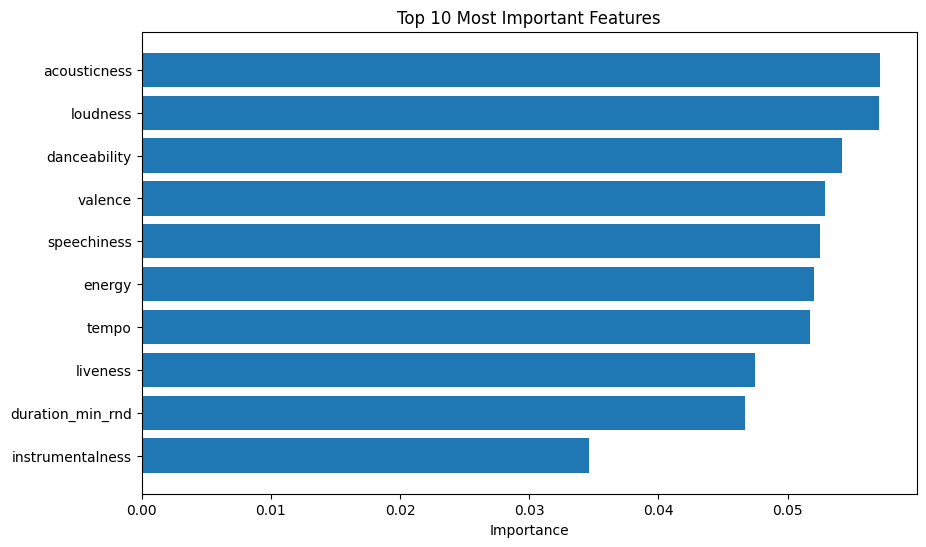

In [30]:
# see what the most important features are
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], 
         feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Most important on top
plt.show()

In [34]:
# Step 5 - evaluate my model
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE,r2_score


In [ ]:
# look at the r2 score - 1 is perfect, 0  is no better than just predicting the mean
r2 = r2_score(y_test, y_pred) 
print(r2)

0.5042297326465275


In [ ]:
# Look at the mean absolute Error  - the average difference between the real and actual values in the same units as the target variable
mae = MAE(y_test, y_pred)
print(mae)

9.650376350892175


In [26]:
# root mean squared error - similar to MAE but punishes large errors more heavily
import numpy as np
rmse = np.sqrt(MSE(y_test, y_pred))
print(rmse)

14.507838995965134


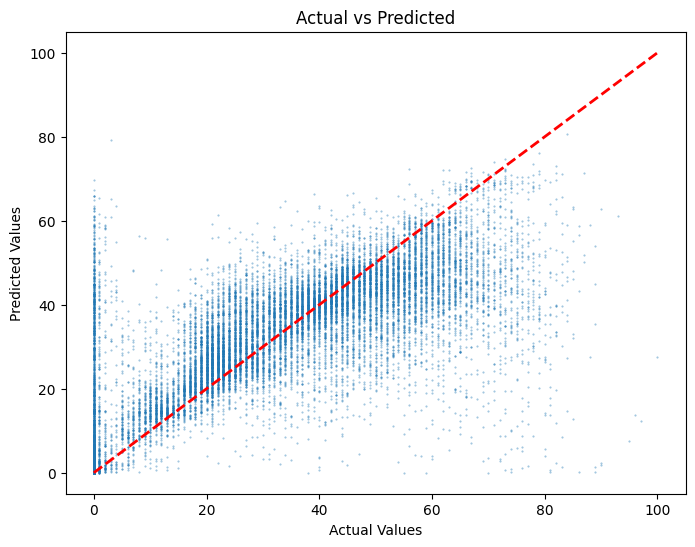

In [30]:
import matplotlib.pyplot as plt

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s = 0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

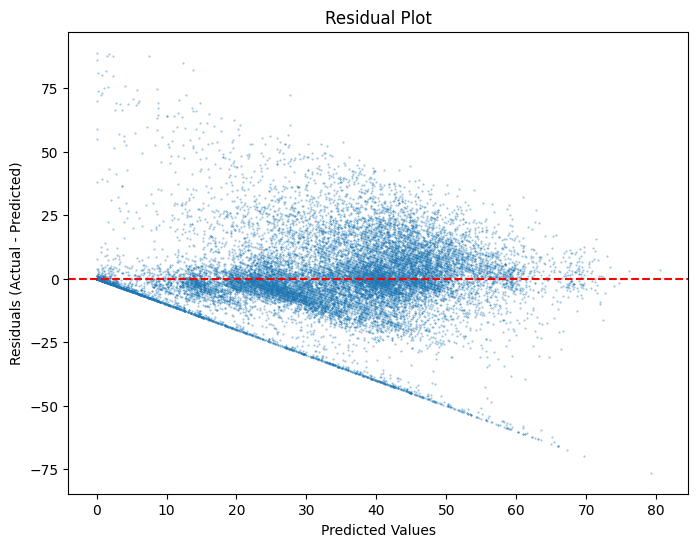

In [31]:
# residual plot
# Residuals = errors
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, s = 0.2)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

In [32]:
print(f"Model Evaluation:")
print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Model Evaluation:
R² Score: 0.504
MAE: 9.65
RMSE: 14.51


In [40]:
# it seems this model is just ok. I wonder can I improve it by hyper-parameter tuning
# do a grid search
from sklearn.model_selection import GridSearchCV

param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 5],
            }

# define the metrics to use for model evaluation
scoring = {
            'r2': 'r2', 
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
}

# define a generic model with the hyperparameters that won't vary
rf = RandomForestRegressor(random_state = 42
                           , n_jobs = -1)

# Define the grid search
gs = GridSearchCV(estimator = rf,
                  param_grid = param_grid, 
                  cv = 5,
                  scoring = scoring,
                  refit = 'r2',
                  return_train_score = True,
                  verbose = 2                           
)

gs.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ....................max_depth=None, n_estimators=50; total time=  48.6s
[CV] END ....................max_depth=None, n_estimators=50; total time=  47.3s
[CV] END ....................max_depth=None, n_estimators=50; total time=  47.0s
[CV] END ....................max_depth=None, n_estimators=50; total time=  49.6s
[CV] END ....................max_depth=None, n_estimators=50; total time=  47.8s
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.5min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.5min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.5min
[CV] END ...................max_depth=None, n_estimators=200; total time= 3.0min
[CV] END ...................max_depth=None, n_est

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mae': 'neg_mean_absolute_error', 'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [41]:
# get the results
results = gs.cv_results_
r2 = results['mean_test_r2']
mae = -results['mean_test_mae']
rmse = -results['mean_test_rmse']

In [42]:
# output the results from best r2 score to worst
rf_results = pd.DataFrame({
    "params": results["params"],
    "r2": r2,
    "mae": mae,
    "rmse": rmse
}).sort_values("r2", ascending=False)

print(rf_results)

                                     params        r2        mae       rmse
2  {'max_depth': None, 'n_estimators': 200}  0.500675   9.716577  14.531914
1  {'max_depth': None, 'n_estimators': 100}  0.498227   9.743513  14.567529
0   {'max_depth': None, 'n_estimators': 50}  0.493023   9.785062  14.642872
4     {'max_depth': 5, 'n_estimators': 100}  0.102238  15.947228  19.485864
3      {'max_depth': 5, 'n_estimators': 50}  0.102100  15.949155  19.487362
5     {'max_depth': 5, 'n_estimators': 200}  0.101983  15.947164  19.488636


In [43]:
print(results)

{'mean_fit_time': array([ 47.79973197,  90.11257854, 175.39836187,   4.60505929,
         8.76041675,  16.87000194]), 'std_fit_time': array([1.00951533, 3.34000704, 4.21172085, 0.21770084, 0.4224322 ,
       0.81636843]), 'mean_score_time': array([0.35940995, 0.46140804, 0.76638522, 0.07320905, 0.09112659,
       0.14157667]), 'std_score_time': array([0.15066276, 0.08917128, 0.11618831, 0.0056914 , 0.00745843,
       0.00902501]), 'param_max_depth': masked_array(data=[None, None, None, 5, 5, 5],
             mask=[False, False, False, False, False, False],
       fill_value=np.str_('?'),
            dtype=object), 'param_n_estimators': masked_array(data=[50, 100, 200, 50, 100, 200],
             mask=[False, False, False, False, False, False],
       fill_value=999999), 'params': [{'max_depth': None, 'n_estimators': 50}, {'max_depth': None, 'n_estimators': 100}, {'max_depth': None, 'n_estimators': 200}, {'max_depth': 5, 'n_estimators': 50}, {'max_depth': 5, 'n_estimators': 100}, {'max_

In [44]:
# this approach didn't help
# what if the group that are not popular are removed?

# make a second version to work with
df_rf2 = df_rf

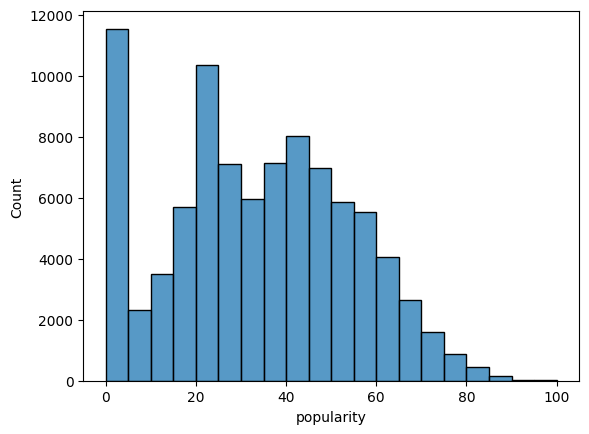

In [45]:
# view a histogram of popularity
sns.histplot(data = df_rf2, x = 'popularity', bins = 20)
plt.show()

In [47]:
# there are a lot where the popularity is less than 5
# investigate this a little
unpop_df = df_rf2[df_rf2['popularity'] <= 5]
print(unpop_df.head())

    popularity  explicit  key_exp  ...  trip_hop  turkish  world_music
6            0     False        4  ...     False    False        False
31           0     False        4  ...     False    False        False
32           0     False        0  ...     False    False        False
39           0     False        9  ...     False    False        False
50           0     False        4  ...     False    False        False

[5 rows x 129 columns]


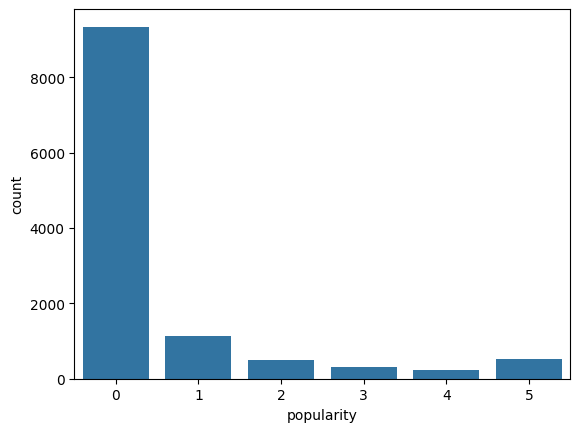

In [48]:
sns.countplot(data = unpop_df, x = 'popularity')
plt.show()

In [49]:
# most are 0, so strip out the zeros as they are likely skewing things a bit
df_rf2 = df_rf2[df_rf2['popularity'] != 0]

In [50]:
df_rf2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80393 entries, 0 to 89739
Columns: 129 entries, popularity to world_music
dtypes: Int64(1), boolean(116), float64(11), int64(1)
memory usage: 26.5 MB


In [ ]:
# run the grid search again to see if this improves the metrics